<a href="https://colab.research.google.com/github/Scotti00/2025_ML_EES/blob/main/Permafrost_valais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rock Glacier-Based Permafrost Mapping of the Valais using Random Forest Classifier

#### Mattia Scotti - December 2025

#### Machine Learning for Earth and Environmental Sciences

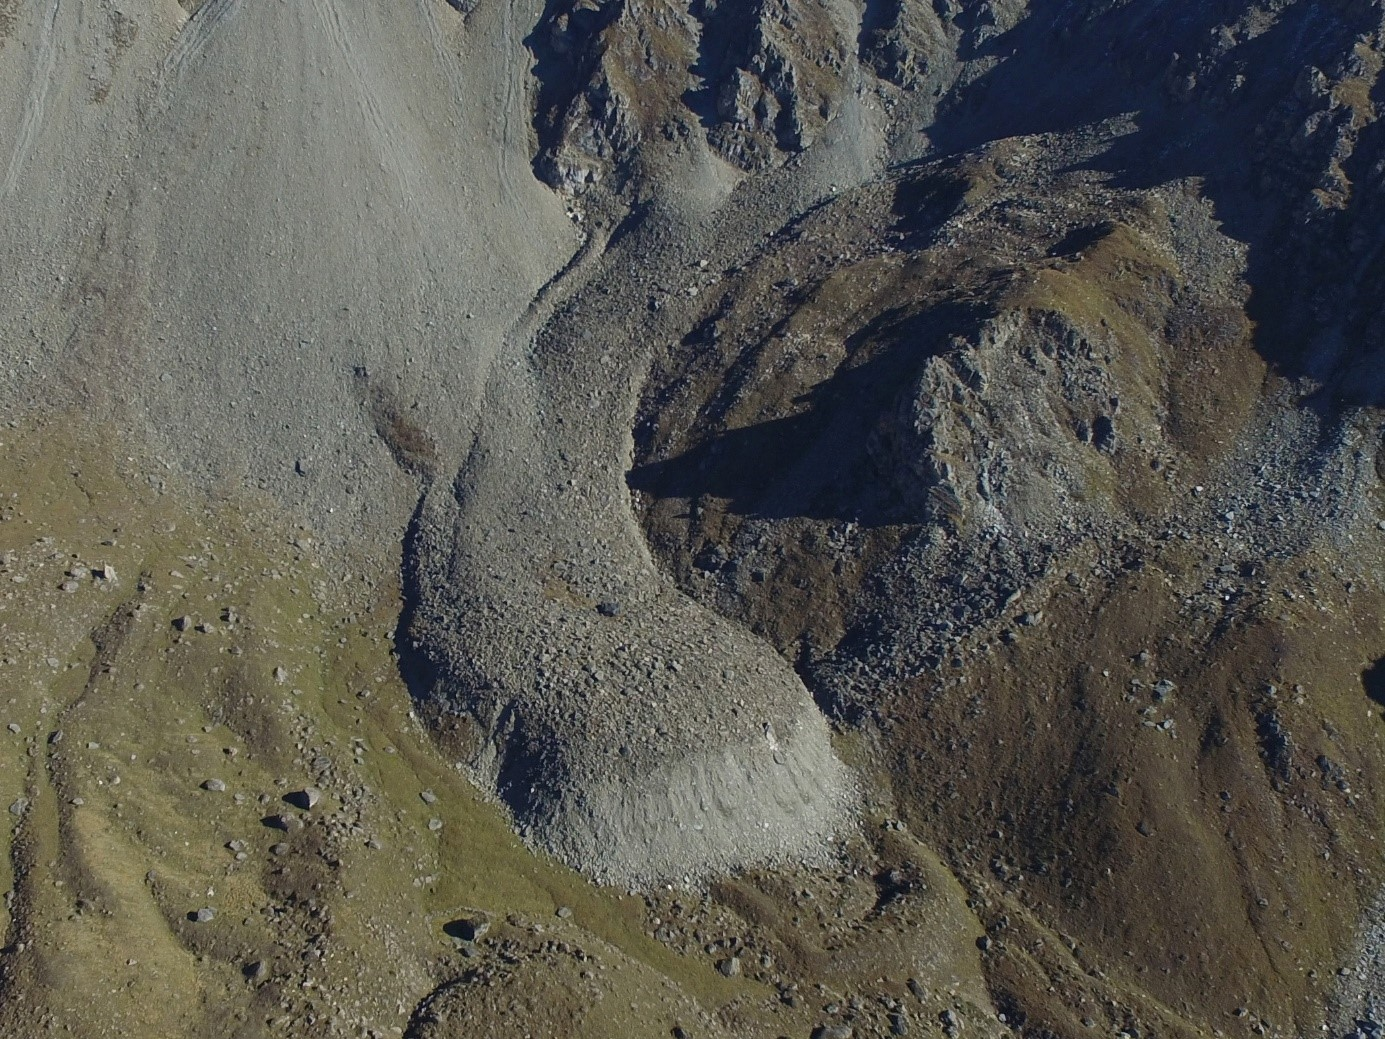

*Les Cliosses active rock glacier, Val d'Hérens (Valais, Switzerland) (Photo : IPA AG Rock glaciers)*


## Introduction

This notebook aims to verify whether an inventory of rock glaciers can be used to train a Random Forest Classifier model in order to produce a continuous map of the probability of permafrost occurrence in the Canton of Valais.

## Notebook Setup

To begin, let's import some libraries that will be useful for the rest of the analysis and verify that the installed versions are correct.

In [15]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# To plot figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

## Import and Explore the Dataset

The dataset used includes the rock glaciers of the Canton of Valais (updated as of October 2025), identified as part of the Swiss rock glacier inventory currently being developed within the RoDynAlpS project. More information about the project can be found at the following link: https://www.unifr.ch/geo/geomorphology/en/research/rodynalps.html

The inventory of the Canton of Valais contain a total of 2384 rock glaciers, which are divided into intact rock glaciers (1391), labeled as permafrost present (1), and relict rock glaciers (993), labeled as permafrost absent (0).

The following nine features will be used as explanatory variables in the model:
* Elevation
* Aspect
* Slope
* Average annual temperature (1961–1990)
* Thawing Degree Days (2002–2020)
* Freezing Degree Days (2002–2020)
* Mean Annual Normalized Difference Snow Index (2014–2024)
* Mean Annual Normalized Difference Vegetation Index (2014–2024)
* Lithology (6 classes)

In [16]:
import pandas as pd

# Provide access to google drive for direct data retrieval
from google.colab import drive
drive.mount('/content/drive')

# Import the dataset with the inventory of Valais rock glaciers
df = pd.read_csv('/content/drive/MyDrive/rockglaciers_valais.csv', sep = ',')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# Let's see what the dataset looks like
print("Inventory of Valais rock glaciers:")
df.head()

Inventory of Valais rock glaciers:


,X,Y,Permafrost,elev,aspect,slope,temp,TDD,FDD,NDSI,NDVI,litho
0,2.551749e+06,1.137373e+06,0,561.261963,26.068291,16.872950,9.250000,3702.747070,119.341339,-0.377388,0.684076,2
1,2.555107e+06,1.136348e+06,0,474.370239,55.140503,11.094762,8.799999,3716.125000,139.561111,-0.463439,0.753728,1
2,2.599958e+06,1.135415e+06,1,2592.159180,315.377777,29.897985,-1.366250,1546.962769,1663.520874,0.855883,-0.199001,2
3,2.599993e+06,1.135304e+06,1,2639.612061,301.215149,32.291214,-1.400000,1585.248779,1628.152344,0.637020,-0.187776,2
4,2.600276e+06,1.135638e+06,1,2611.110107,320.681854,18.124624,-1.851250,1444.930542,1812.657349,0.550024,-0.153552,2


## Data Preprocessing

First, the dataset must be separated into feature and target datasets.

In [18]:
# Definition of feature (X) and target (Y)
feature_cols = ['elev', 'slope', 'aspect', 'temp', 'TDD', 'FDD', 'NDVI', 'NDSI', 'litho']
X = df[feature_cols]
y = df['Permafrost']

Then, we separate the feature and the target datasets into a training (80%) and a test (20%) set. In this case, it is not necessary to create a validation set because RandomizedSearchCV and GridSearchCV will be used to optimize the hyperparameters. These two methods automatically create a validation set from the training set using cross-validation. The test set is then used to evaluate the model's ability to generalize on data not observed during training.

In [19]:
from sklearn.model_selection import train_test_split

# Divide into training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,   # To make the results reproducible
    stratify=y         # To ensure that the permafrost/non-permafrost ratio remains similar in all sets
)

We can check the shape of the training and test sets and make sure that they have been divided into the correct proportions.

In [20]:
# Total number of samples
n_total = len(df)

# Dimensions of the sets
n_train = X_train.shape[0]
n_test  = X_test.shape[0]

# Percentages
perc_train = n_train / n_total * 100
perc_test  = n_test  / n_total * 100

print(f"Training set:   {n_train} ({perc_train:.2f}%)")
print(f"Test set:       {n_test}  ({perc_test:.2f}%)")
print(f"Total:          {n_total} (100%)")

Training set:   1907 (79.99%)
Test set:       477  (20.01%)
Total:          2384 (100%)


### Correlation Matrix

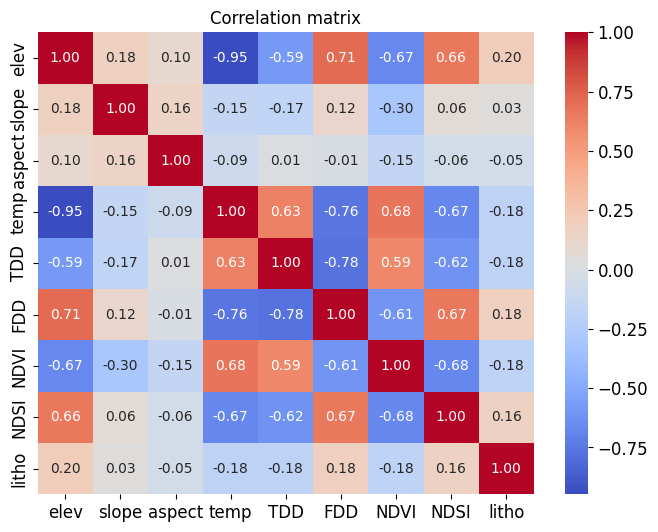

In [21]:
import seaborn as sns

# Calculation of the correlation matrix
corr_matrix = df[feature_cols].corr()

# Plot of the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation matrix")
plt.show()

As expected, climatic variables together with the two indices show strong correlations with elevation, where temperature, TDD, and NDVI show a negative correlation while FDD and NDSI show a positive correlation. On the contrary, morphological variables appear to be more independent.

## Construction of the Random Forest model

The Random Forest algorithm is based on decision trees and builds a "forest" composed of multiple trees, where each tree is trained on a different sample of the data. By combining the predictions from all the trees, the final prediction is obtained.

We will use RandomSearchCV to explore wide ranges of hyperparameters without trying every single combinations to reduce the computational cost.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

*(The following cell can take up to 25 minutes to run. If you want to speed it up, you can reduce the value of "n_iter", but you will test less combinations.)*

In [23]:
# 1) Initialize the model
model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',       # Tells the model that a class is rarer and automatically calculates the weights
)

# 2) Define the hyperparameters and the range for the search
param_dist = {
    'n_estimators': np.arange(1, 601, 10),      # The number of trees in the forest
    'max_depth': np.arange(5, 20, 1),           # The maximum depth of the tree
    'max_features': [None],                     # All features are considered when looking for the best split (fixed)
    'min_samples_split': np.arange(2, 10, 1),   # The minimum number of samples required to split an internal node
    'min_samples_leaf': np.arange(2, 10, 1),    # The minimum number of samples required to be at a leaf node
    'criterion': ['entropy'],                   # The function to measure the quality of a split (fixed)
    'bootstrap': [True]                         # Resampling method (fixed)
}

# 3) Configure the RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=100,                       # Number of combinations to test
    cv=5,                             # 5-fold cross-validation, creation of the validation set (20% of the train set)
    scoring='accuracy',               # Evaluation metric
    n_jobs=-1,                        # Use all available cores
    random_state=42,
)

# 4) Perform the random search on the training set
random_search.fit(X_train, y_train)

# 5) Display the best hyperparameters found with the corresponding accuracy
print("Best hyperparameters (randomized search): ", random_search.best_params_)
print("Accuracy with best parameters: ", random_search.best_score_)

>>> Perfroming a randomized search (rough phase)...
Best hyperparameters (randomized search):  {'n_estimators': np.int64(171), 'min_samples_split': np.int64(6), 'min_samples_leaf': np.int64(2), 'max_features': None, 'max_depth': np.int64(10), 'criterion': 'entropy', 'bootstrap': True}
Accuracy with best parameters:  0.8411139052644596


Some hyperparameters are fixed because they have never changed even after multiple runs.

Once the best hyperparameters have been found, the model can be retrained.

In [24]:
# Final model with the best hyperparameters
best_params = random_search.best_params_
final_model = RandomForestClassifier(
    **best_params,
    random_state=42)

# Training of the model
final_model.fit(X_train, y_train)

# Evaluate the model on the test set
y_test_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Final model accuracy on the test set: {test_accuracy:.4f}")

# Display the classification report for more detailed metrics
print("\nClassification report for the test set (Final model):")
print(classification_report(y_test, y_test_pred))

# Display the confusion matrix for the test set
print("\nConfusion matrix for the test set (Final model):")
print(confusion_matrix(y_test, y_test_pred))


Final model accuracy on the test set: 0.8218

Classification report for the test set (Final model):
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       199
           1       0.81      0.90      0.86       278

    accuracy                           0.82       477
   macro avg       0.83      0.81      0.81       477
weighted avg       0.82      0.82      0.82       477


Confusion matrix for the test set (Final model):
[[141  58]
 [ 27 251]]


The accuracy on the training set (84.11%) and on the test set (82.18%) is good. Furthermore, the fact that the accuracy on the test set is very similar to that on the training set means that the model did not overfit during training.

## Model Perfromance Analysis

Please note that each time RandomizedSearchCV is run, the best hyperparameters may change slightly, and therefore the accuracy and other performance metrics may differ slightly from the values reported in my comments.

### Confusion Matrix

The confusion matrix is a table that summarizes the performance of a classification model by comparing the model's predictions with the actual values.

For a binary problem, the matrix consists of four elements:

* True Positive (TP): positive instances correctly classified as positive

* True Negative (TN): negative instances correctly classified as negative

* False Positive (FP): negative instances incorrectly classified as positive

* False Negative (FN): positive instances incorrectly classified as negative

A confusion matrix therefore shows how and where the model is wrong, not just how accurate it is.

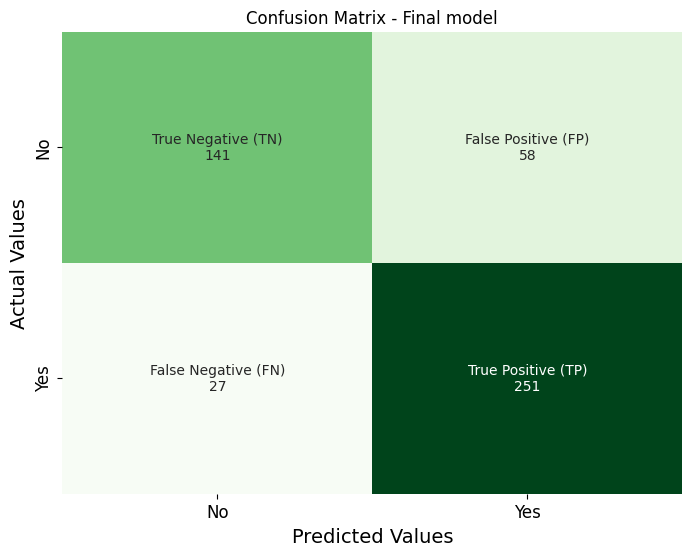

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Define the labels for each cell
labels = ['True Negative (TN)', 'False Positive (FP)', 'False Negative (FN)', 'True Positive (TP)']
label_counts = [f"{label}\n{value}" for label, value in zip(labels, conf_matrix.flatten())]
label_counts = np.array(label_counts).reshape(2, 2)

# Plot the confusion matrix with annotations
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=label_counts, fmt='', cmap='Greens', cbar=False,
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])

plt.title("Confusion Matrix - Final model")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

The confusion matrix shows good model performance, with a high number of true positives (251) and true negatives (141) and relatively few errors, indicating good discriminating power. However, the positive class appears to be handled better than the negative class.

### ROC Curve / AUC

The ROC curve shows a model's ability to distinguish between classes by plotting the relationship between true positives and false positives, while the AUC quantifies this ability in a single value between 0 and 1, where higher values indicate a better discriminating performance.

Area Under the ROC Curve: 0.9139


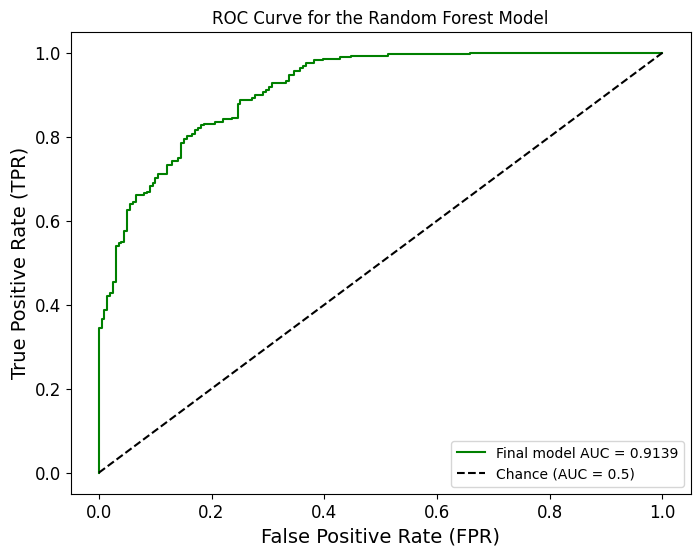

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute probabilities for the permafrost (positive class)
y_proba = final_model.predict_proba(X_test)[:, 1]

# Compute values for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute the AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"Area Under the ROC Curve: {auc_score:.4f}")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Final model AUC = {auc_score:.4f}', color='green')
plt.plot([0, 1], [0, 1], 'k--', label="Chance (AUC = 0.5)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for the Random Forest Model")
plt.legend(loc="lower right")
plt.show()

The ROC curve shows that the Random Forest model has a very good discriminating ability. The curve stays well above the random diagonal, showing that the model can effectively tell the difference between the presence and absence of permafrost. The AUC value of 0.9139 confirms its high performance: values above 0.9 are generally considered very good.

### Feature importances

Feature importance measures the relative contribution of each variable to the predictive power of the Random Forest model. It is based on how much each feature improves the quality of splits during training. The total is then normalized so that all importances add up to 1. In practice, the more the feature contributes to the model's decisions, the higher its importance will be, and vice versa. A feature with an importance of 0 means that it is never used for splits.

  Feature  Importance
6    NDVI    0.531691
0    elev    0.104711
7    NDSI    0.090198
2  aspect    0.060135
1   slope    0.058747
4     TDD    0.050690
5     FDD    0.047024
3    temp    0.046431
8   litho    0.010373


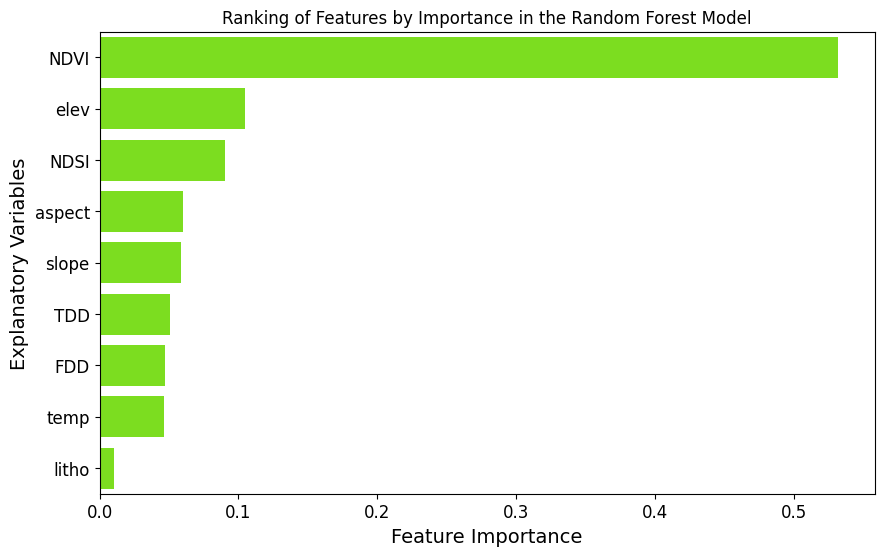

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the feature importances from the model
importances = final_model.feature_importances_

# Link each feature to its importance score
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
    }).sort_values(by='Importance', ascending=False)
print(feat_imp)

# To plot a bar chart of feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, color='LawnGreen')
plt.title("Ranking of Features by Importance in the Random Forest Model")
plt.xlabel("Feature Importance")
plt.ylabel("Explanatory Variables")
plt.show()

Feature importance shows that NDVI is by far the most influential variable in the Random Forest model, contributing alone to more than half of the total predictive power. This is followed by elev, NDSI, aspect, slope, TDD, temp, and FDD, which have moderate and similar importance. Litho, on the other hand, is not very informative for the model, suggesting that lithology has a very limited impact on predictions compared to the other features considered.

The importance attributed to NDVI lies in the fact that intact rock glaciers, being in permafrost conditions and in motion (advancing downward due to permafrost creep), do not allow vegetation to grow. On the contrary, relict rock glaciers, being stable and no longer in permafrost conditions, allow vegetation to grow and are in most cases characterized by higher NDVI values. This feature is therefore recognized by the model as very reliable, more than other features such as altitude, since at the same altitude we can have both intact and relict rock glaciers depending on the aspect of the slope.

### Partial Dependance Plot (PDP)

Partial Dependence Plots (PDP) are used to understand how the features influence the average prediction of the model.

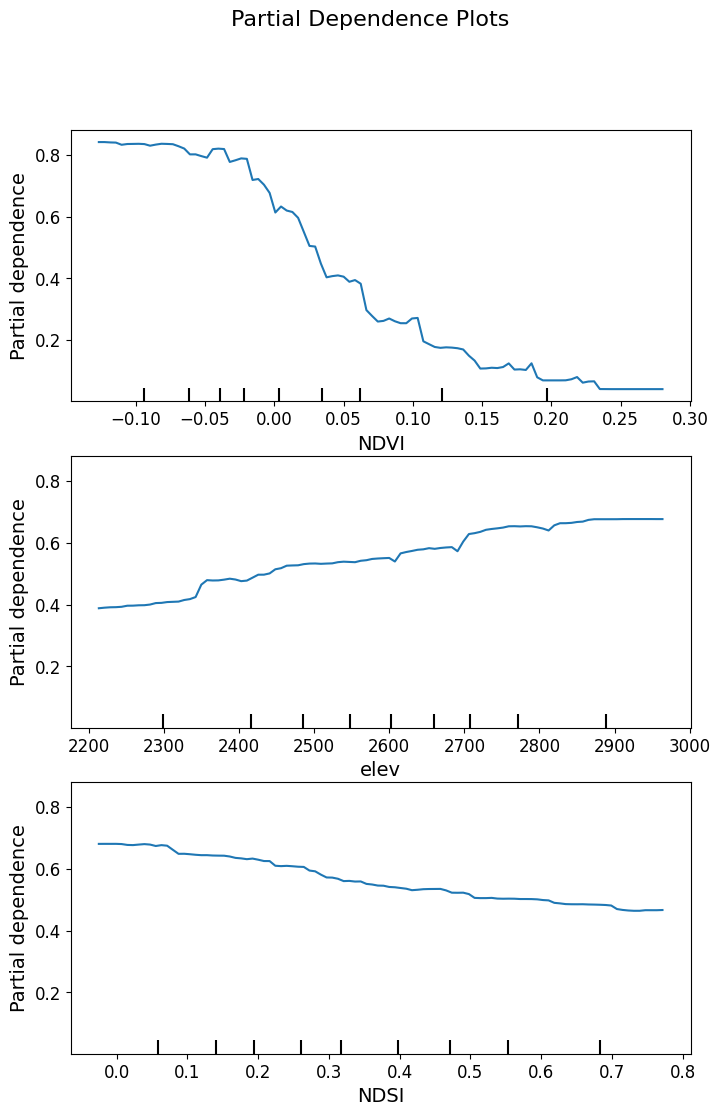

In [28]:
from sklearn.inspection import PartialDependenceDisplay

# Select the indices of the 3 most important variables
feat_imp_idx = feat_imp.index[:3]

# Create a figure and subplots
fig, ax = plt.subplots(len(feat_imp_idx), figsize=(8, 4 * len(feat_imp_idx)), sharex=False)

# Generate the PDP
display = PartialDependenceDisplay.from_estimator(
    final_model,
    X_test,
    feat_imp_idx,
    feature_names=X_train.columns,
    ax=ax
)

# General title
plt.suptitle("Partial Dependence Plots", fontsize=16)
plt.show()

The analysis of the Partial Dependence Plots highlights relationships consistent with the processes that control the presence of permafrost. The NDVI shows a strongly negative effect: as vegetation cover decreases, the probability of permafrost increases significantly, in line with the characteristics of intact rock glaciers. Elevation, on the other hand, shows a positive relationship, confirming that lower temperatures at higher altitudes favor the presence of permafrost. Finally, the NDSI shows a moderately negative influence, reflecting the fact that high mountain areas where snow struggles to accumulate, for example due to wind or steep slopes, are less isolated from winter frost and can therefore cool down better and more easily maintain permafrost conditions. However, this relationship is only slightly negative, since the higher you go, the more snow there tends to be.

## Permafrost Probability Map

It is now possible to use the final Random Forest model to attempt to create a continuous map of the probability of permafrost occurrence across the entire surface of the Valais.

### Import all the rasters

First, the rasters of the nine features covering the entire territory of Valais with a spatial resolution of 25 meters must be imported. In addition, it is also necessary to import the raster to create the mask for lakes and glaciers.

In [29]:
import rasterio

# Set the base folder in MyDrive
base_path = "/content/drive/MyDrive"

# Define the raster paths
dem_path            = os.path.join(base_path, "dem_valais_25m.tif")
slope_path          = os.path.join(base_path, "slope_valais_25m.tif")
aspect_path         = os.path.join(base_path, "aspect_valais_25m.tif")
temp_path           = os.path.join(base_path, "temp_valais_25m.tif")
tdd_path            = os.path.join(base_path, "TDD_valais_25m.tif")
fdd_path            = os.path.join(base_path, "FDD_valais_25m.tif")
ndvi_path           = os.path.join(base_path, "NDVI_valais_25m.tif")
ndsi_path           = os.path.join(base_path, "NDSI_valais_25m.tif")
litho_path          = os.path.join(base_path, "lithology_valais_25m.tif")
lakes_glaciers_path = os.path.join(base_path, "lakes_glaciers_valais_25m.tif")

# Import of the rasters
# We set the dem as reference
with rasterio.open(dem_path) as src_dem:
    dem = src_dem.read(1).astype(np.float32)
    profile = src_dem.profile
    height, width = dem.shape

with rasterio.open(slope_path)          as src:  slope          = src.read(1).astype(np.float32)
with rasterio.open(aspect_path)         as src:  aspect         = src.read(1).astype(np.float32)
with rasterio.open(temp_path)           as src:  temp           = src.read(1).astype(np.float32)
with rasterio.open(tdd_path)            as src:  TDD            = src.read(1).astype(np.float32)
with rasterio.open(fdd_path)            as src:  FDD            = src.read(1).astype(np.float32)
with rasterio.open(ndvi_path)           as src:  NDVI           = src.read(1).astype(np.float32)
with rasterio.open(ndsi_path)           as src:  NDSI           = src.read(1).astype(np.float32)
with rasterio.open(litho_path)          as src:  litho          = src.read(1).astype(np.float32)
with rasterio.open(lakes_glaciers_path) as src:  lakes_glaciers = src.read(1)

We will stack the various rasters so that they can be transformed into a data table (2D matrix) readable by the Random Forest model, where each row will correspond to a pixel and each column to a feature.

In [30]:
# Stack of the features
stack = np.stack(
    [dem, slope, aspect, temp, TDD, FDD, NDVI, NDSI, litho],
    axis=-1
)  # shape: (rows, cols, n_features)

rows, cols, n_features = stack.shape
X_all = stack.reshape(-1, n_features)

print("Stack shape:", stack.shape)
print("X_all shape:", X_all.shape)

Stack shape: (3554, 5246, 9)
X_all shape: (18644284, 9)


### Masks for missing values, lakes, and glaciers

We create a mask to exclude glaciers and lakes, as these areas are not considered for the presence of permafrost. We also exclude pixels with missing values, if any.

In [31]:
# Mask to exclude glaciers and lakes
mask_lakes_glaciers = (lakes_glaciers == 1)

# Mask pixels with at least one NaN in any variable (to be excluded)
mask_nan = np.any(np.isnan(stack), axis=-1)

# Definition of valid pixels
valid_mask = ((~mask_lakes_glaciers)
              & (~mask_nan))

# Flatten to work in 1D
valid_mask_flat = valid_mask.ravel()
X_valid = X_all[valid_mask_flat]
print("Number of valid pixels for prediction:", X_valid.shape[0])

Number of valid pixels for prediction: 17707346


### Map Creation

Now everything is ready to create the map by applying the Random Forest model to all valid pixels.

In [32]:
# Prediction only on valid pixels
probs_valid = final_model.predict_proba(X_valid)[:, 1]

# Creation of a complete map
prob_map = np.full((rows * cols), np.nan, dtype="float32")
prob_map[valid_mask_flat] = probs_valid

# Reshape into raster form (2D)
prob_map = prob_map.reshape((rows, cols))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


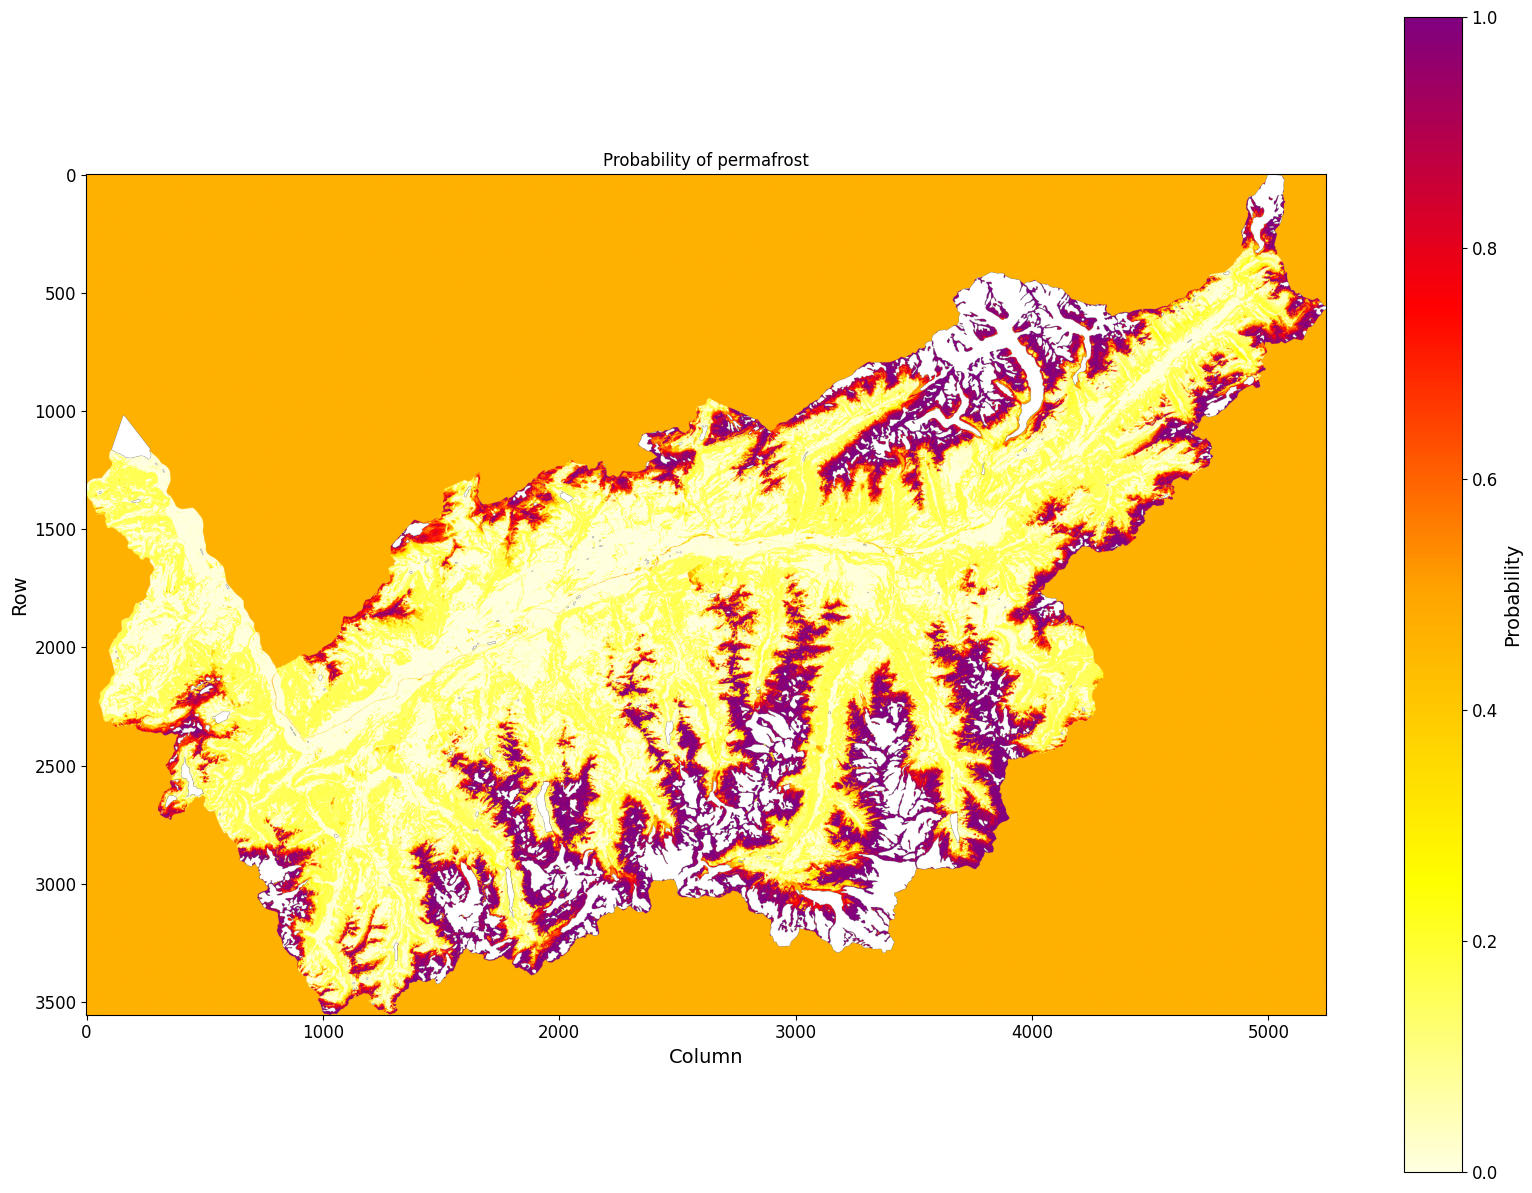

In [33]:
# Create a custom colormap
import matplotlib.colors as mcolors

colors = ["LightYellow", "yellow", "orange", "red", "purple"]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Plot the figure
plt.figure(figsize=(20, 15))
im = plt.imshow(prob_map, vmin=0, vmax=1, cmap=cmap)
plt.title("Probability of permafrost")
plt.colorbar(im, label="Probability")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

After analyzing the map in a GIS environment, it can be seen that the prediction of permafrost distribution is generally accurate. The model correctly identifies the presence of permafrost in high mountain areas and also credibly reproduces the differences between north- and south-facing slopes.

However, some critical issues emerge in relatively low-altitude areas, where the model predicts the presence of permafrost even along some stretches of the Rhone River and in areas without vegetation. This behavior is consistent with what is indicated by feature importance: the NDVI variable, in fact, contributes more than 50% to the model's decisions. The NDVI therefore becomes a dominant feature, leading the model to overestimate the presence of permafrost in all areas characterized by little or no vegetation cover.

This phenomenon suggests a form of overfitting towards the NDVI. The reason can be interpreted from a geomorphological point of view: as mentioned earlier, intact rock glaciers are generally free of vegetation, while fossil glaciers often have vegetation cover. By learning this relationship, the model tends to systematically classify even low-altitude areas without vegetation as “permafrost,” even though they do not have compatible thermal or altimetric characteristics.

To improve the quality of the prediction, a useful step may be to build a new version of the model excluding the NDVI, in order to assess how much this feature affects overall performance and verify whether spatial accuracy improves by reducing false positives at low altitudes.

In [34]:
###----(OPTIONAL - TO EXPORT THE MAP)----###

import rasterio
import numpy as np

# Set the output path
output_path = "/content/drive/MyDrive/permafrost_probability_valais_25m"

# Set the profile from the DEM to have correct CRS, transform, and resolution
out_profile = profile.copy()
out_profile.update(
    dtype="float32",
    count=1,
    nodata=np.nan
)

# ensure float32
to_save = prob_map.astype("float32")

# add the band dimension
to_save = np.expand_dims(to_save, axis=0)

# write the file
with rasterio.open(output_path, "w", **out_profile) as dst:
    dst.write(to_save)

print("Raster saved successfully in:", output_path)

Raster saved successfully in: /content/drive/MyDrive/permafrost_probability_valais_25m


## Random Forest Model - no NDVI

In [49]:
from sklearn.model_selection import cross_val_score

# 1) Remove NDVI from existing sets
X_train_noNDVI = X_train.drop(columns=["NDVI"])
X_test_noNDVI  = X_test.drop(columns=["NDVI"])

# 2) Instantiating the new model withe the best hyperparameters found above
noNDVI_model = RandomForestClassifier(
    **best_params,
    random_state=42)

# 3) Cross validation
cv_scores = cross_val_score(
    noNDVI_model,
    X_train_noNDVI,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV accuracy mean (no NDVI):", cv_scores.mean())

# 4) Train the new model
noNDVI_model.fit(X_train_noNDVI, y_train)

# 5) Evaluation on the test set
y_pred_noNDVI = noNDVI_model.predict(X_test_noNDVI)
test_accuracy_noNDVI = accuracy_score(y_test, y_pred_noNDVI)

print("Accuracy on the test set without NDVI:", test_accuracy_noNDVI)

# 6) Display the classification report for more detailed metrics
print("\nClassification report for the test set (Final model):")
print(classification_report(y_test, y_pred_noNDVI))

#  7) Display the confusion matrix for the test set
print("\nConfusion matrix for the test set (Final model):")
print(confusion_matrix(y_test, y_pred_noNDVI))

CV accuracy mean (no NDVI): 0.8017740583474187
Accuracy on the test set without NDVI: 0.80083857442348

Classification report for the test set (Final model):
              precision    recall  f1-score   support

           0       0.77      0.75      0.76       199
           1       0.83      0.83      0.83       278

    accuracy                           0.80       477
   macro avg       0.80      0.79      0.79       477
weighted avg       0.80      0.80      0.80       477


Confusion matrix for the test set (Final model):
[[150  49]
 [ 46 232]]


As expected, given that NDVI is a very important feature for distinguishing relict rock glaciers from intact ones, accuracy has decreased slightly. However, our goal is to produce a more accurate map, so we will evaluate later whether it is a good choice to remove NDVI from the features.

## Second Model Perfromance Analysis

### Confusion Matrix

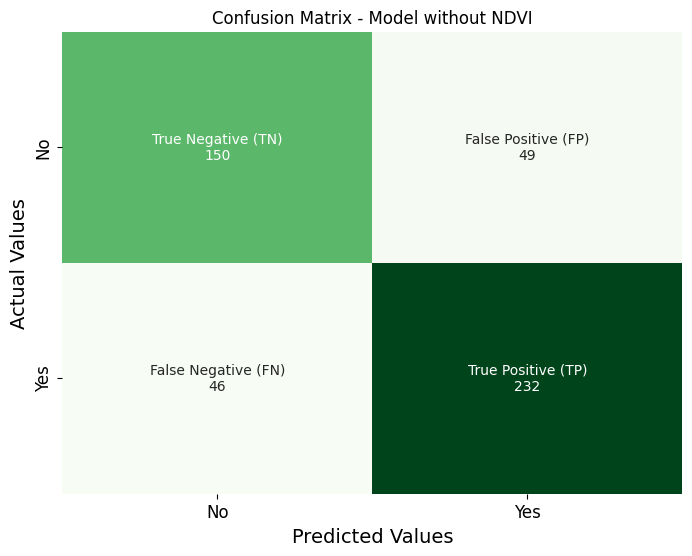

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix_noNDVI = confusion_matrix(y_test, y_pred_noNDVI)

# Define the labels for each cell
labels = ['True Negative (TN)', 'False Positive (FP)', 'False Negative (FN)', 'True Positive (TP)']
label_counts = [f"{label}\n{value}" for label, value in zip(labels, conf_matrix_noNDVI.flatten())]
label_counts = np.array(label_counts).reshape(2, 2)

# Plot the confusion matrix with annotations
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_noNDVI, annot=label_counts, fmt='', cmap='Greens', cbar=False,
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])

plt.title("Confusion Matrix - Model without NDVI")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

The model without NDVI shows fewer false positives (49 vs. 58) and more true negatives (150 vs. 141), so it is more conservative in predicting permafrost. However, it recognizes actual permafrost less well, with more false negatives (43 vs. 27) and fewer true positives (235 vs. 251). In summary, removing NDVI would seem to slightly reduce overestimations but decrease the model's ability to correctly identify permafrost.



### ROC Curve / AUC

Area Under the ROC Curve: 0.8812


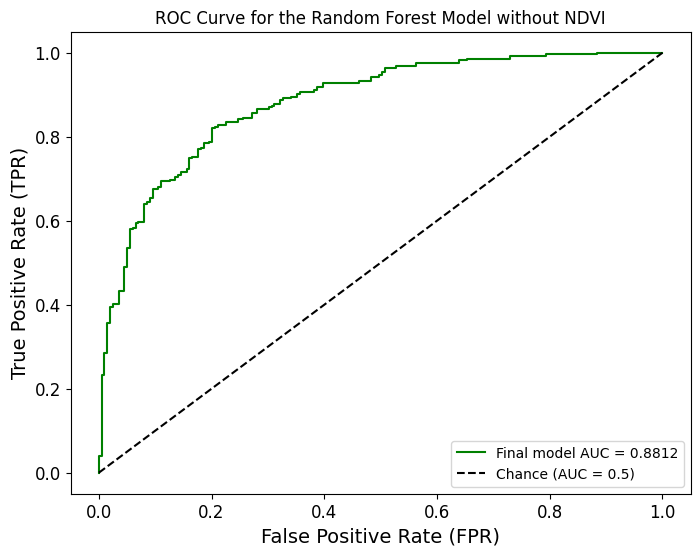

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute probabilities for the permafrost (positive class)
y_proba_noNDVI = noNDVI_model.predict_proba(X_test_noNDVI)[:, 1]

# Compute values for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_noNDVI)

# Compute the AUC
auc_score = roc_auc_score(y_test, y_proba_noNDVI)
print(f"Area Under the ROC Curve: {auc_score:.4f}")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Final model AUC = {auc_score:.4f}', color='green')
plt.plot([0, 1], [0, 1], 'k--', label="Chance (AUC = 0.5)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for the Random Forest Model without NDVI")
plt.legend(loc="lower right")
plt.show()

The ROC curve shows that the new Random Forest model still has good discriminatory ability, even though the AUC value has fallen below the threshold of 0.9.

### Feature importance

  Feature  Importance
0    elev    0.376750
2  aspect    0.198527
1   slope    0.101167
4     TDD    0.088217
6    NDSI    0.073016
5     FDD    0.071163
3    temp    0.068316
7   litho    0.022843


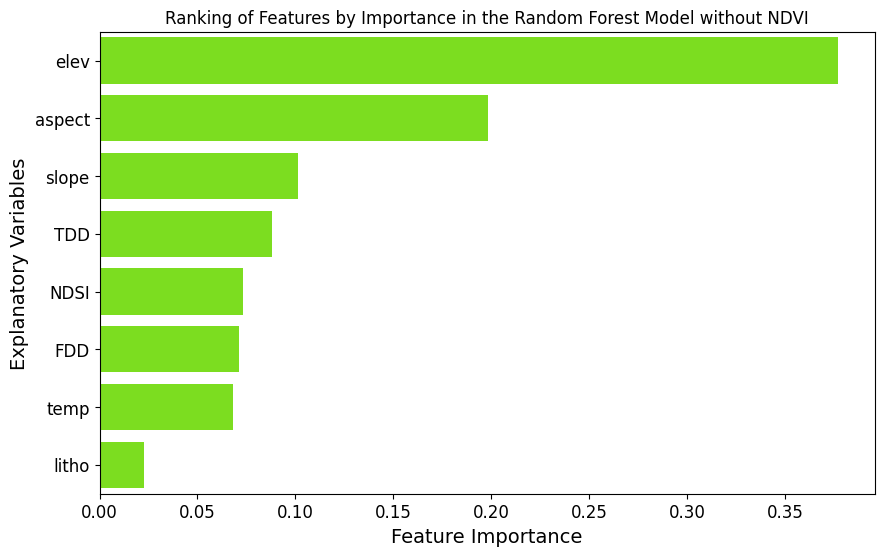

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the feature importances from the model
importances_noNDVI = noNDVI_model.feature_importances_

# Get the features
feature_names = X_train_noNDVI.columns

# Link each feature to its importance score
feat_imp_noNDVI = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_noNDVI
    }).sort_values(by='Importance', ascending=False)
print(feat_imp_noNDVI)

# To plot a bar chart of feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_noNDVI, color='LawnGreen')
plt.title("Ranking of Features by Importance in the Random Forest Model without NDVI")
plt.xlabel("Feature Importance")
plt.ylabel("Explanatory Variables")
plt.show()

As might be expected, elevation is the most important feature, followed by aspect, two morphological elements that are very important for the distribution of permafrost.

### Partial Dependence Plots (PDP)

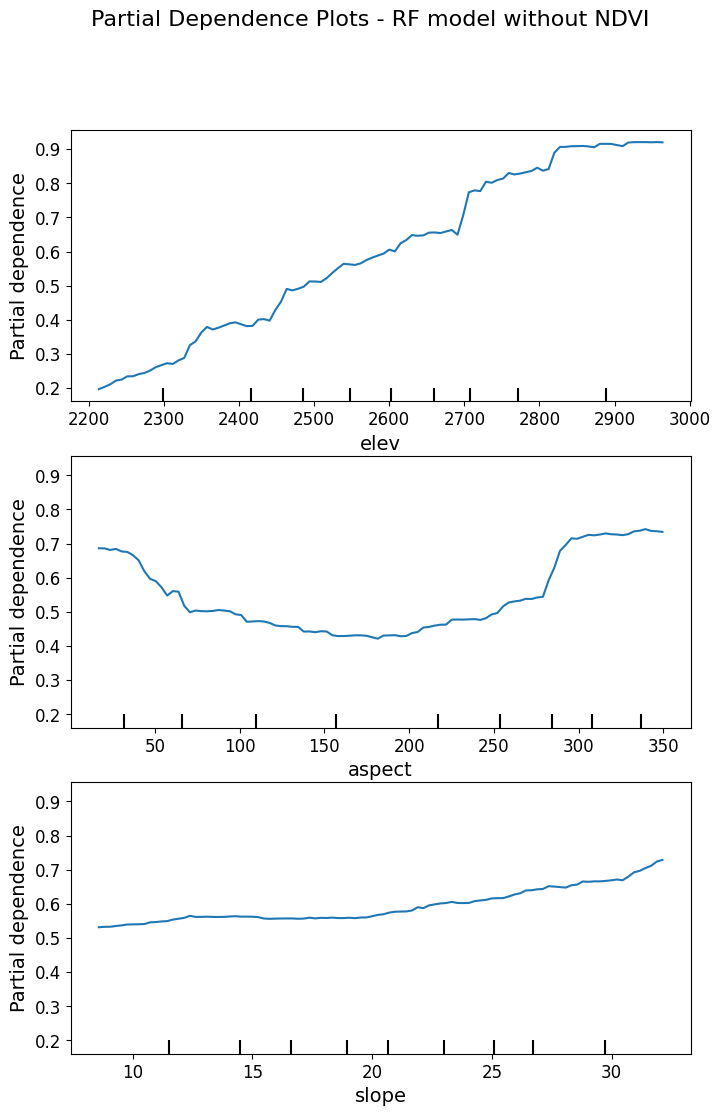

In [39]:
from sklearn.inspection import PartialDependenceDisplay

# Select the indices of the 3 most important variables
feat_imp_noNDVI_idx = feat_imp_noNDVI.index[:3]

# Create a figure and subplots
fig, ax = plt.subplots(len(feat_imp_noNDVI_idx), figsize=(8, 4 * len(feat_imp_noNDVI_idx)), sharex=False)

# Generate the PDP
display = PartialDependenceDisplay.from_estimator(
    noNDVI_model,
    X_test_noNDVI,
    feat_imp_noNDVI_idx,
    feature_names=X_train_noNDVI.columns,
    ax=ax
)

# General title
plt.suptitle("Partial Dependence Plots - RF model without NDVI", fontsize=16)
plt.show()

The PDPs show that elevation has a strongly positive effect on the probability of permafrost, while aspect shows minimum values on south-facing slopes and higher values on north-facing slopes. Slope, on the other hand, has a weak but increasing influence, indicating that steeper slopes are slightly more favorable to permafrost.

## Second Permafrost Probability Map

In [40]:
# Stack of the features without NDVI
stack_noNDVI = np.stack(
    [dem, slope, aspect, temp, TDD, FDD, NDSI, litho],
    axis=-1
    )

rows, cols, n_features = stack_noNDVI.shape
X_all_noNDVI = stack_noNDVI.reshape(-1, n_features)

print("Stack shape:", stack.shape)
print("X_all_noNDVI shape:", X_all_noNDVI.shape)

Stack shape: (3554, 5246, 9)
X_all_noNDVI shape: (18644284, 8)


In [41]:
# Only select valid pixels from the dataframe without NDVI
X_valid_noNDVI = X_all_noNDVI[valid_mask_flat]

# Prediction only on valid pixels
probs_valid_noNDVI = noNDVI_model.predict_proba(X_valid_noNDVI)[:, 1]

# Creation of a complete map
prob_map_noNDVI = np.full((rows * cols), np.nan, dtype="float32")
prob_map_noNDVI[valid_mask_flat] = probs_valid_noNDVI

# Reshape into raster form (2D)
prob_map_noNDVI = prob_map_noNDVI.reshape((rows, cols))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


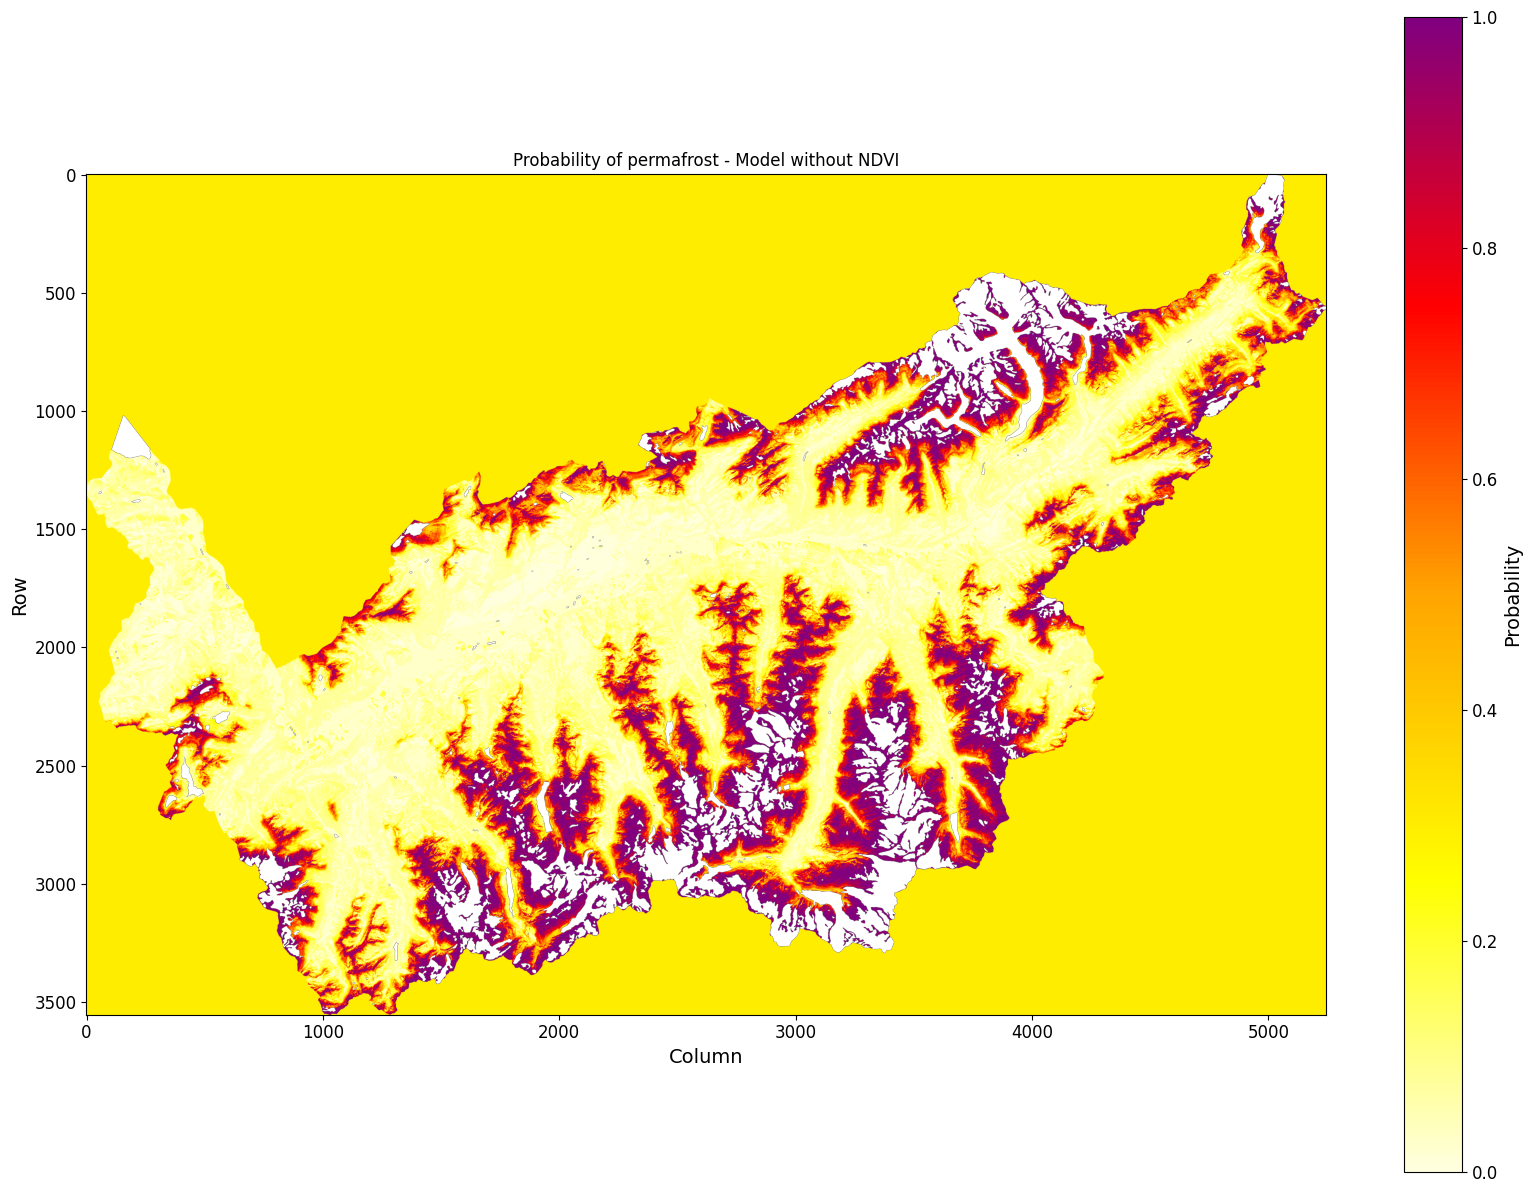

In [42]:
# Plot the figure
plt.figure(figsize=(20, 15))
im = plt.imshow(prob_map_noNDVI, vmin=0, vmax=1, cmap=cmap)
plt.title("Probability of permafrost - Model without NDVI")
plt.colorbar(im, label="Probability")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

In [43]:
###----(OPTIONAL - TO EXPORT THE MAP with no NDVI)----###

import rasterio
import numpy as np

# Set the output path
output_path = "/content/drive/MyDrive/permafrost_probability_noNDVI_valais_25m"

# Set the profile from the DEM to have correct CRS, transform, and resolution
out_profile = profile.copy()
out_profile.update(
    dtype="float32",
    count=1,
    nodata=np.nan
)

# ensure float32
to_save = prob_map_noNDVI.astype("float32")

# add the band dimension
to_save = np.expand_dims(to_save, axis=0)

# write the file
with rasterio.open(output_path, "w", **out_profile) as dst:
    dst.write(to_save)

print("Raster saved successfully in:", output_path)

Raster saved successfully in: /content/drive/MyDrive/permafrost_probability_noNDVI_valais_25m
